<a href="https://www.kaggle.com/code/sm39sinp/brain-tumor-detection?scriptVersionId=328370824" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Brain Tumor Detection from MRI Images using CNN and MobileNetV2

This notebook demonstrates a complete deep learning pipeline for binary classification of brain MRI scans into:

- Tumor
- No Tumor

The workflow includes:

1. Dataset preparation
2. Exploratory Data Analysis (EDA)
3. Duplicate image detection
4. Train-validation split
5. Data augmentation
6. Custom CNN model
7. Transfer Learning using MobileNetV2
8. Fine-tuning
9. Model evaluation
10. Grad-CAM explainability

Author: Soumen Mondal

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

import os
import shutil
import random
import hashlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/34 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N20.JPG
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N1.JPG
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/49 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N15.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/No18.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/31 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 6.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/3 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 5.jpeg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 1.jpg
/kaggle/input/datasets/navoneel/brain-mri-i

2026-06-18 17:12:26.931773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781802747.096159      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781802747.147594      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781802747.548093      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781802747.548131      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781802747.548133      23 computation_placer.cc:177] computation placer alr

# Dataset Preparation

The MRI dataset contains two classes:

- `yes` : MRI images containing brain tumors
- `no` : MRI images without tumors

The dataset is copied into the working directory to allow preprocessing and training.

In [2]:

#Copy Dataset to Working Directory
SOURCE_DIR = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"

WORK_DATASET = "/kaggle/working/brain_dataset"

shutil.copytree(
    SOURCE_DIR,
    WORK_DATASET,
    dirs_exist_ok=True
)

work_dir = "/kaggle/working/brain_split"

In [3]:
#imporing data

YES_DIR = os.path.join(WORK_DATASET, "yes")
NO_DIR = os.path.join(WORK_DATASET, "no")

print(YES_DIR)
print(NO_DIR)


/kaggle/working/brain_dataset/yes
/kaggle/working/brain_dataset/no


# Exploratory Data Analysis (EDA)

Before training a deep learning model, it is important to understand:

- Number of samples in each class
- Class imbalance
- Visual appearance of images
- Variation in image dimensions

This section provides an overview of the dataset.

In [4]:
#Checking Class Distribution

yes_count = len(os.listdir(YES_DIR))
no_count = len(os.listdir(NO_DIR))

print("Tumor:", yes_count)
print("No Tumor:", no_count)

Tumor: 155
No Tumor: 98


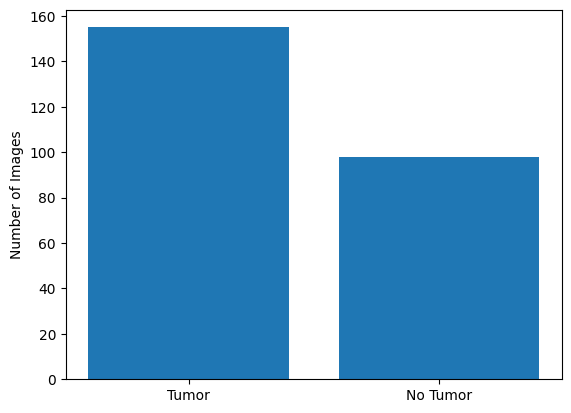

In [5]:
#Ploting the Class Distribution

plt.bar(['Tumor', 'No Tumor'],
        [yes_count, no_count])

plt.ylabel('Number of Images')
plt.show()

## Sample MRI Images

Visual inspection helps verify:

- Image quality
- Anatomical variations
- Presence or absence of tumors
- Potential artifacts

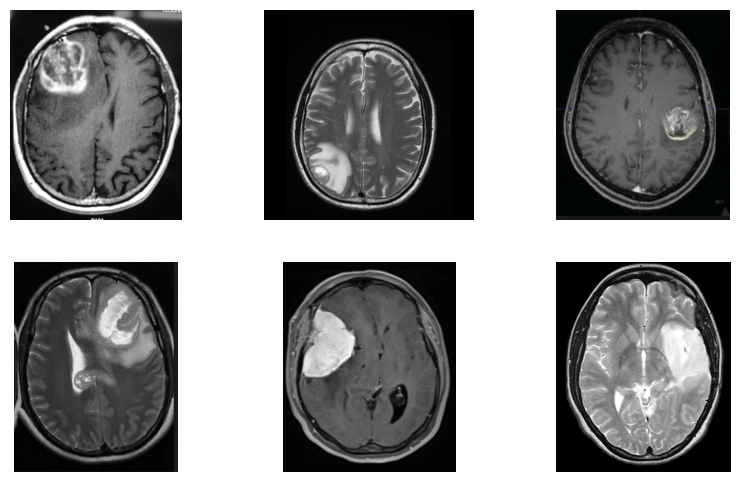

In [6]:
#Visualize Random Images

files = random.sample(
    os.listdir(YES_DIR),
    6
)

plt.figure(figsize=(10,6))

for i, file in enumerate(files):

    img = Image.open(
        os.path.join(YES_DIR, file)
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

## Image Resolution Analysis

MRI images may have different widths and heights.

Understanding the size distribution helps determine an appropriate input size for neural network training.

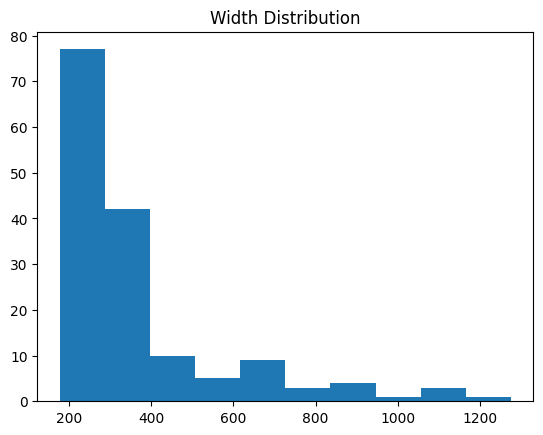

In [7]:
#Image Dimension Distribution
widths = []
heights = []

for file in os.listdir(YES_DIR):

    img = Image.open(
        os.path.join(YES_DIR, file)
    )

    widths.append(img.size[0])
    heights.append(img.size[1])

plt.hist(widths)
plt.title("Width Distribution")
plt.show()

# Duplicate Image Detection and Removal

Duplicate images can lead to:

- Data leakage
- Inflated validation accuracy
- Biased model performance

To avoid this, image hashes are used to identify and remove duplicates from both classes.

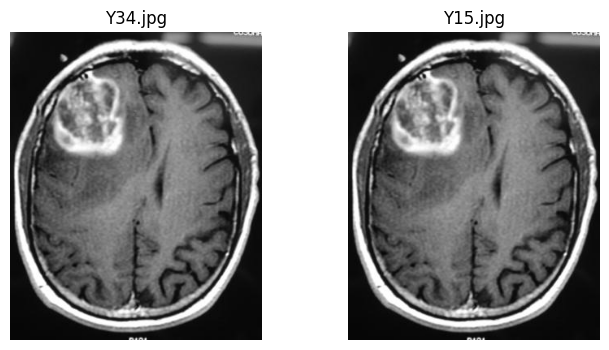

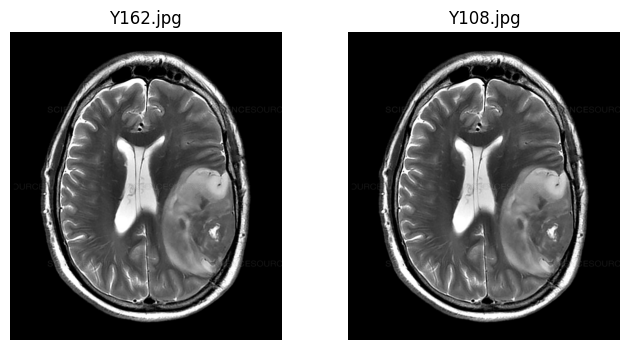

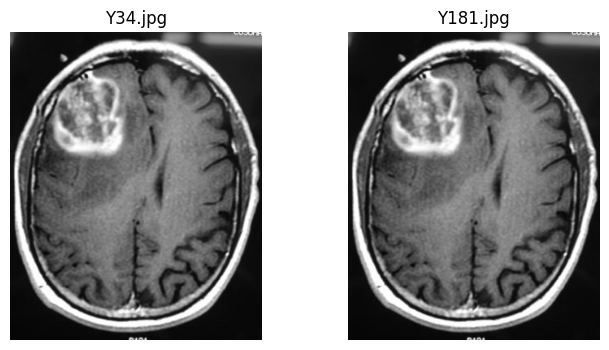

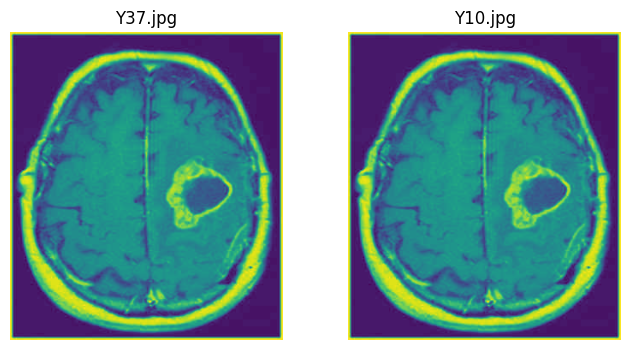

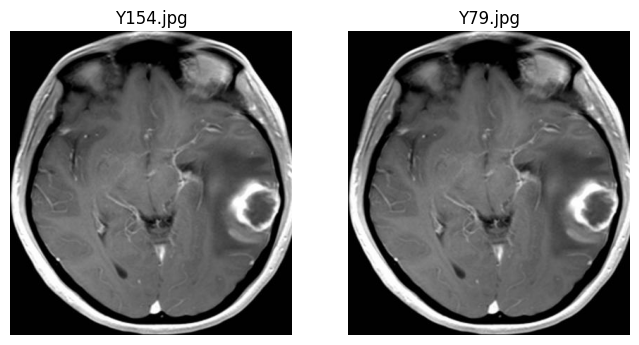

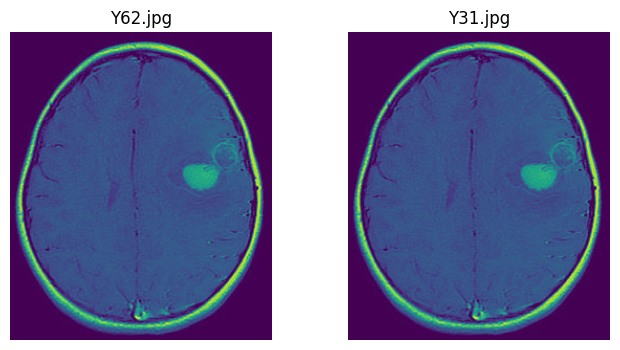

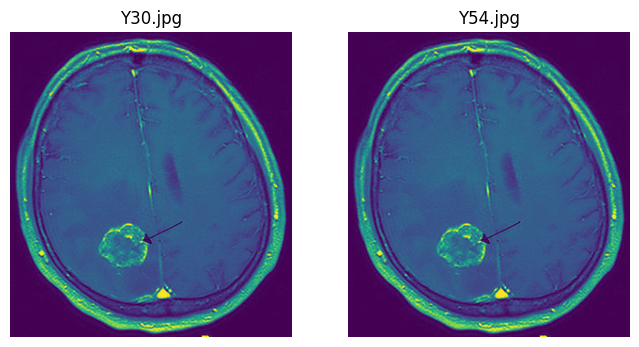

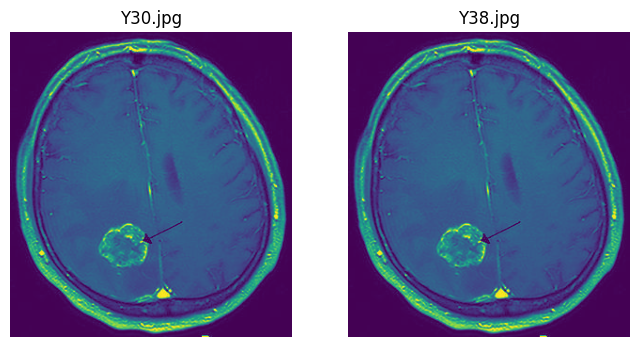

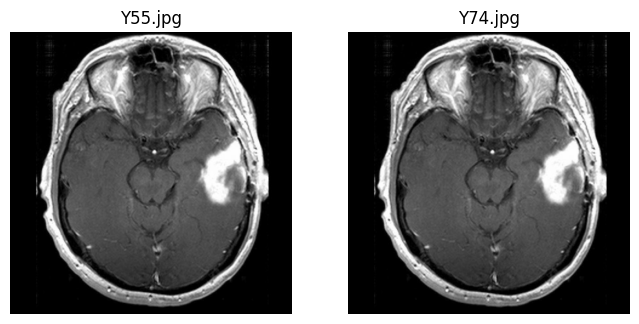

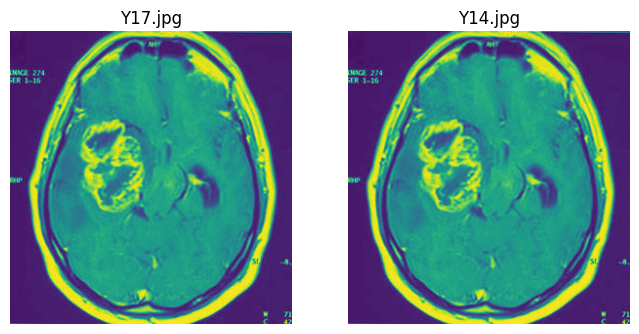

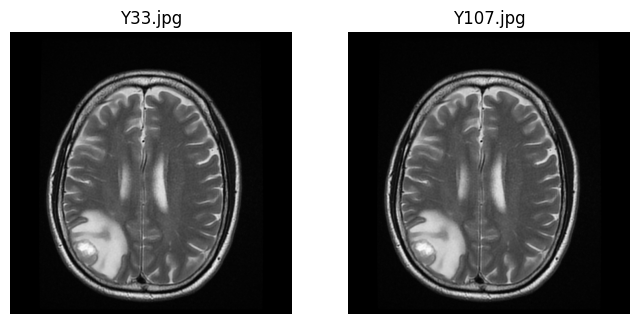

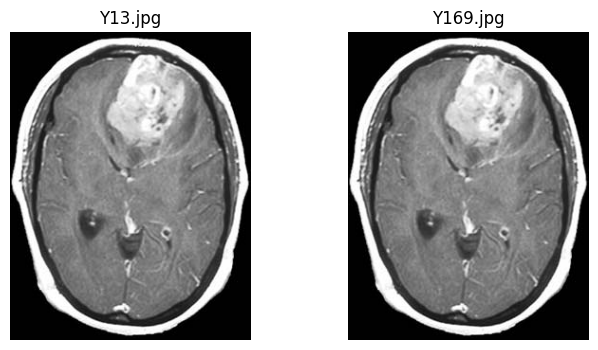

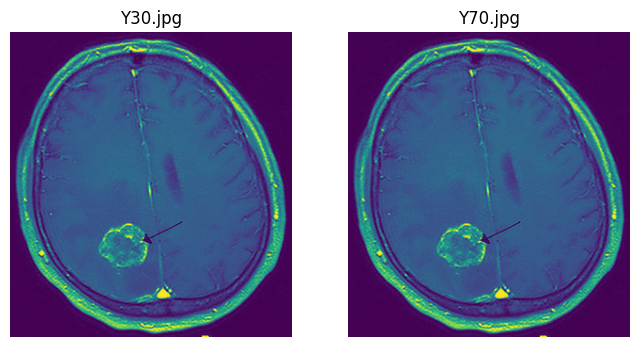

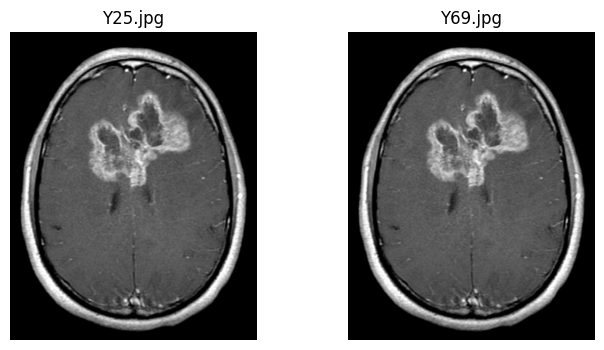

In [8]:
#Check the Duplicates in YES
hash_dict = {}

for file in os.listdir(YES_DIR):

    path = os.path.join(YES_DIR, file)

    with open(path, 'rb') as f:

        h = hashlib.md5(f.read()).hexdigest()

    if h in hash_dict:

        original = hash_dict[h]

        img1 = Image.open(
            os.path.join(YES_DIR, original)
        )

        img2 = Image.open(path)

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img1)
        plt.title(original)
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(img2)
        plt.title(file)
        plt.axis('off')

        plt.show()

    else:
        hash_dict[h] = file

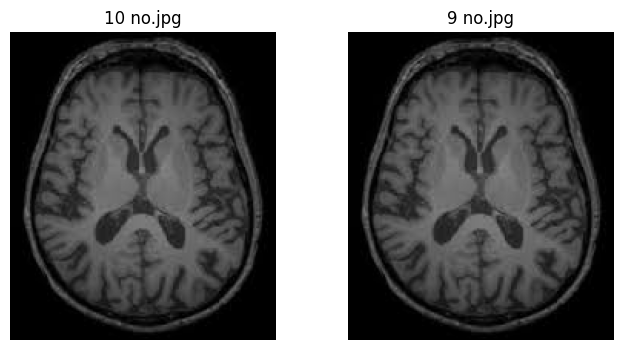

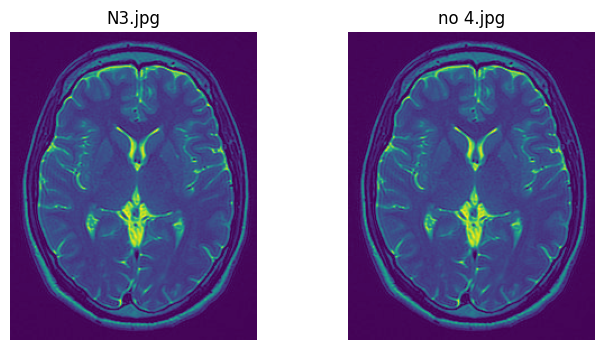

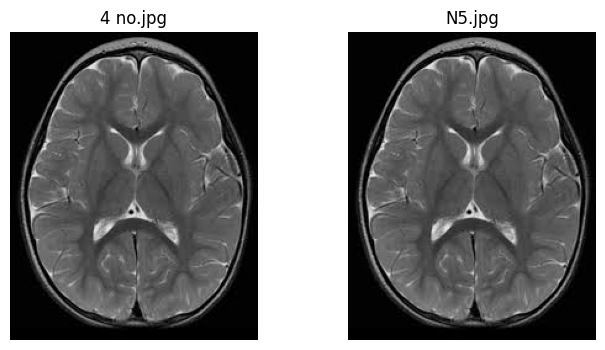

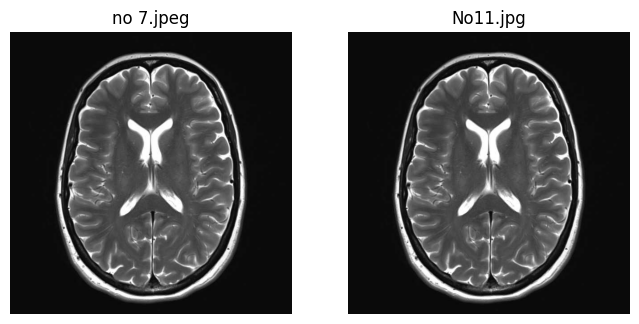

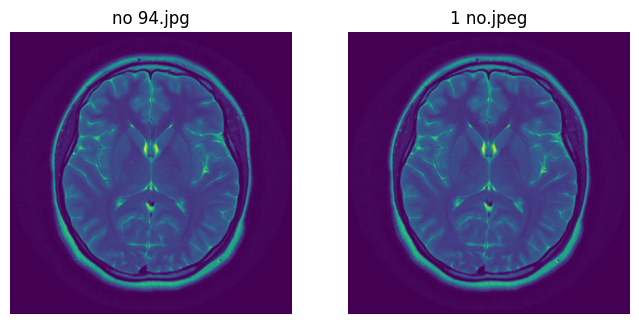

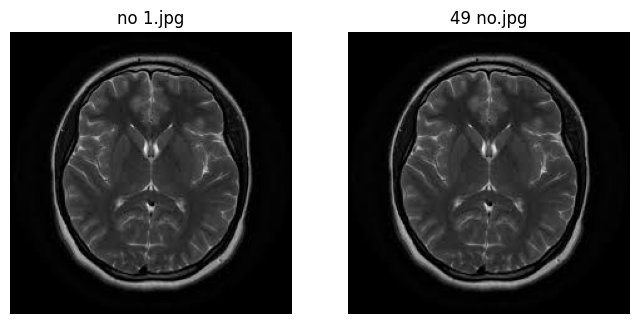

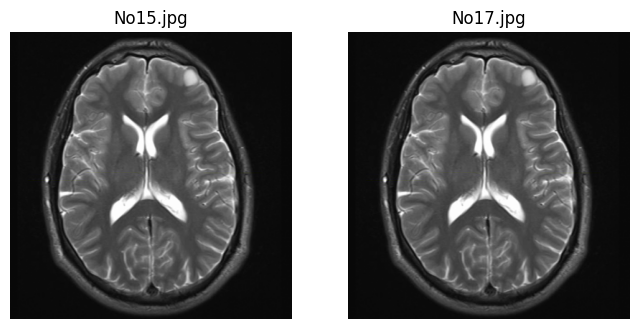

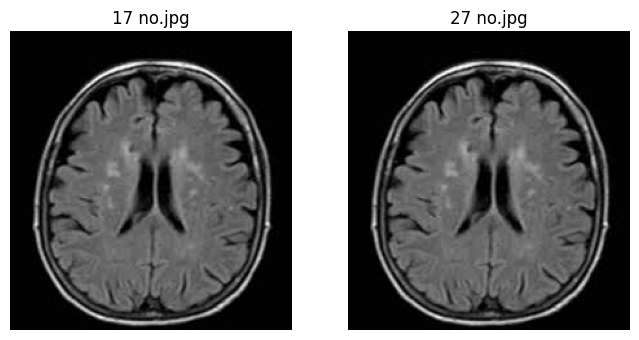

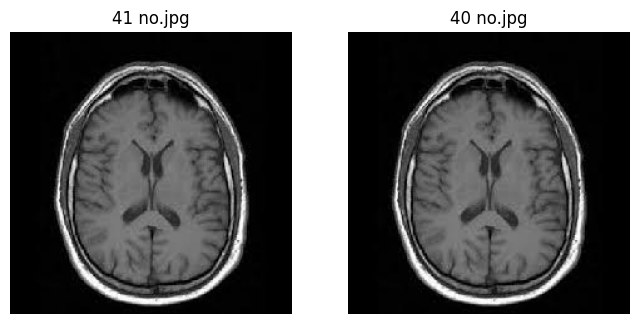

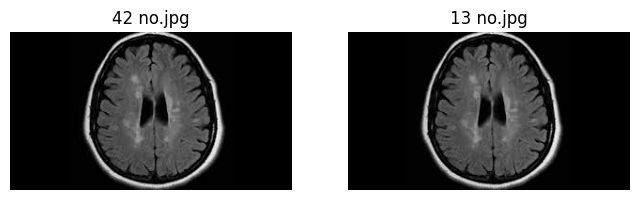

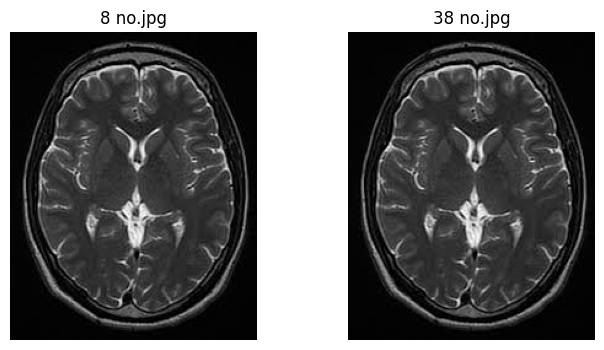

In [9]:
#Check the Duplicates in NO

hash_dict = {}

for file in os.listdir(NO_DIR):

    path = os.path.join(NO_DIR, file)

    with open(path, 'rb') as f:

        h = hashlib.md5(f.read()).hexdigest()

    if h in hash_dict:

        original = hash_dict[h]

        img1 = Image.open(
            os.path.join(NO_DIR, original)
        )

        img2 = Image.open(path)

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img1)
        plt.title(original)
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(img2)
        plt.title(file)
        plt.axis('off')

        plt.show()

    else:
        hash_dict[h] = file

In [10]:
#Removing Duplicates from YES
hashes = set()

for file in os.listdir(YES_DIR):

    path = os.path.join(YES_DIR, file)

    with open(path, 'rb') as f:
        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()

    if file_hash in hashes:
        print("Removing duplicate:", file)
        os.remove(path)

    else:
        hashes.add(file_hash)

Removing duplicate: Y15.jpg
Removing duplicate: Y108.jpg
Removing duplicate: Y181.jpg
Removing duplicate: Y10.jpg
Removing duplicate: Y79.jpg
Removing duplicate: Y31.jpg
Removing duplicate: Y54.jpg
Removing duplicate: Y38.jpg
Removing duplicate: Y74.jpg
Removing duplicate: Y14.jpg
Removing duplicate: Y107.jpg
Removing duplicate: Y169.jpg
Removing duplicate: Y70.jpg
Removing duplicate: Y69.jpg


In [11]:
#Removing Duplicates from NO
hashes = set()

for file in os.listdir(NO_DIR):

    path = os.path.join(NO_DIR, file)

    with open(path, 'rb') as f:
        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()

    if file_hash in hashes:
        print("Removing duplicate:", file)
        os.remove(path)

    else:
        hashes.add(file_hash)

Removing duplicate: 9 no.jpg
Removing duplicate: no 4.jpg
Removing duplicate: N5.jpg
Removing duplicate: No11.jpg
Removing duplicate: 1 no.jpeg
Removing duplicate: 49 no.jpg
Removing duplicate: No17.jpg
Removing duplicate: 27 no.jpg
Removing duplicate: 40 no.jpg
Removing duplicate: 13 no.jpg
Removing duplicate: 38 no.jpg


In [12]:
#Confirm the removal

print("Tumor images:",
      len(os.listdir(YES_DIR)))

print("No tumor images:",
      len(os.listdir(NO_DIR)))

Tumor images: 141
No tumor images: 87


# Train–Validation Split

The dataset is divided into:

- Training set (80%)
- Validation set (20%)

A fixed random seed is used to ensure reproducibility.

In [13]:
# Creating folder paths for training and validation datasets

WORK_DIR = "/kaggle/working/brain_split"

# Path for training images belonging to the "yes" (tumor) class
train_yes = os.path.join(WORK_DIR, "train", "yes")

# Path for training images belonging to the "no" (non-tumor) class
train_no = os.path.join(WORK_DIR, "train", "no")

# Path for validation images belonging to the "yes" (tumor) class
val_yes = os.path.join(WORK_DIR, "validation", "yes")

# Path for validation images belonging to the "no" (non-tumor) class
val_no = os.path.join(WORK_DIR, "validation", "no")

# Create the directories if they do not already exist

for folder in [train_yes, train_no, val_yes, val_no]:

    # Create the directory.
    # exist_ok=True prevents an error if the folder already exists.
    os.makedirs(folder, exist_ok=True)

In [14]:
# seeding produces the same train-validation split every time.
random.seed(42)
# Obtain the list of image filenames from each class folder
# List all image files in the tumor ("yes") folder
yes_files = os.listdir(YES_DIR)

# List all image files in the non-tumor ("no") folder
no_files = os.listdir(NO_DIR)

# Randomly shuffle the filenames

random.shuffle(yes_files)
random.shuffle(no_files)

# Compute the split index for an 80:20 train-validation split
# Compute 80% of the total tumor images
yes_split = int(0.8 * len(yes_files))

# Compute 80% of the total non-tumor images
no_split = int(0.8 * len(no_files))

# Split tumor images into training and validation sets

# First 80% → training set
train_yes_files = yes_files[:yes_split]

# Remaining 20% → validation set
val_yes_files = yes_files[yes_split:]


# Split non-tumor images into training and validation sets

# First 80% → training set
train_no_files = no_files[:no_split]

# Remaining 20% → validation set
val_no_files = no_files[no_split:]

In [15]:
def copy_files(file_list, src_dir, dst_dir):
    for f in file_list:
        shutil.copy(
            os.path.join(src_dir, f),
            os.path.join(dst_dir, f)
        )

copy_files(train_yes_files, YES_DIR, train_yes)
copy_files(val_yes_files, YES_DIR, val_yes)

copy_files(train_no_files, NO_DIR, train_no)
copy_files(val_no_files, NO_DIR, val_no)

In [16]:
print("Train Yes:", len(os.listdir(train_yes)))
print("Train No :", len(os.listdir(train_no)))

print("Val Yes  :", len(os.listdir(val_yes)))
print("Val No   :", len(os.listdir(val_no)))

Train Yes: 112
Train No : 69
Val Yes  : 29
Val No   : 18


# Data Augmentation

Data augmentation artificially increases dataset diversity.

Applied transformations:

- Rotation
- Width shift
- Height shift
- Zoom
- Horizontal flip

This helps reduce overfitting and improve model generalization.

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [18]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "train"),
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "validation"),
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 181 images belonging to 2 classes.
Found 47 images belonging to 2 classes.


## Handling Class Imbalance

Class weights are computed automatically and supplied during training so that minority classes receive higher importance.

In [19]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3115942028985508), 1: np.float64(0.8080357142857143)}


In [20]:
print(train_generator.class_indices)

{'no': 0, 'yes': 1}


In [21]:
labels = train_generator.classes

print("No Tumor :", np.sum(labels == 0))
print("Tumor    :", np.sum(labels == 1))

No Tumor : 69
Tumor    : 112


# Model 1: Custom Convolutional Neural Network (CNN)

A baseline CNN is developed using:

- Convolution layers
- Max pooling layers
- Dropout regularization
- Fully connected layers

This model serves as a benchmark before applying transfer learning.

In [22]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D( 64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D( 128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781802770.585586      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781802770.591546      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30


I0000 00:00:1781802774.183948      86 service.cc:152] XLA service 0x7f58d0004dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781802774.184001      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781802774.184008      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781802774.596213      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-18 17:12:56.402913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:12:56.549105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:09 6s/step - accuracy: 0.3125 - loss: 0.6799

I0000 00:00:1781802778.703406      86 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 6/12 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5347 - loss: 0.7892

2026-06-18 17:13:00.598708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:13:00.742149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 599ms/step - accuracy: 0.5635 - loss: 0.7290 - val_accuracy: 0.5532 - val_loss: 0.6718
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.6464 - loss: 0.6201 - val_accuracy: 0.6809 - val_loss: 0.6340
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.6796 - loss: 0.6422 - val_accuracy: 0.7234 - val_loss: 0.5679
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.6685 - loss: 0.5965 - val_accuracy: 0.7872 - val_loss: 0.5284
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.7403 - loss: 0.5335 - val_accuracy: 0.7447 - val_loss: 0.5391
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.7790 - loss: 0.5269 - val_accuracy: 0.7021 - val_loss: 0.5257
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.7348 - loss: 0.5784 - val_accuracy: 0.8085 - val_loss: 0.5083
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.7901 - loss: 0.5218 - val_accuracy: 0.7660 - val

## Training History

The following plots show:

- Training accuracy
- Validation accuracy
- Training loss
- Validation loss

These metrics help identify overfitting and convergence behavior.

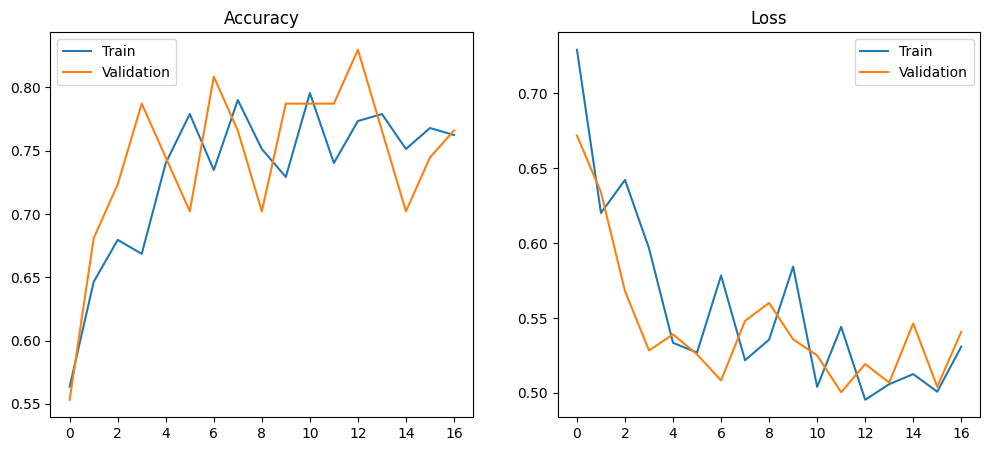

In [25]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Loss')

plt.show()

# Evaluation of Custom CNN

Performance is assessed using:

- Classification Report
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [26]:
from sklearn.metrics import classification_report

y_true = validation_generator.classes

y_prob = model.predict(validation_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step
              precision    recall  f1-score   support

    No Tumor       0.83      0.56      0.67        18
       Tumor       0.77      0.93      0.84        29

    accuracy                           0.79        47
   macro avg       0.80      0.74      0.76        47
weighted avg       0.80      0.79      0.78        47



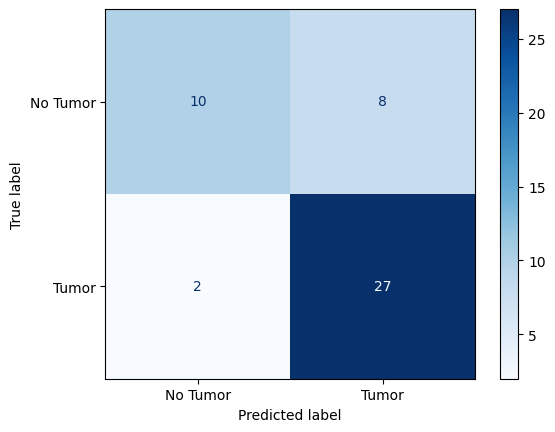

In [27]:
from sklearn.metrics import *
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
).plot(cmap='Blues')

plt.show()

In [28]:
import pickle

with open('/kaggle/working/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [29]:
model.save('/kaggle/working/brain_tumor_model.keras')

# Model 2: Transfer Learning with MobileNetV2

Instead of training from scratch, a pretrained MobileNetV2 model is used.

Advantages:

- Faster convergence
- Better feature extraction
- Higher accuracy on small datasets

The ImageNet-trained weights provide rich visual representations that can be adapted to MRI classification.

In [30]:
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [31]:
train_datagen = ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input
)

In [32]:
train_generator = train_datagen.flow_from_directory(

    os.path.join(WORK_DIR, "train"),

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    shuffle=True
)

Found 181 images belonging to 2 classes.


In [33]:
validation_generator = validation_datagen.flow_from_directory(

    os.path.join(WORK_DIR, "validation"),

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    shuffle=False
)

Found 47 images belonging to 2 classes.


In [34]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3115942028985508), 1: np.float64(0.8080357142857143)}


## Feature Extractor

The pretrained MobileNetV2 backbone is used as a fixed feature extractor.

Initially:

- Convolutional layers are frozen
- Only the classifier head is trained

In [35]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable = False

In [37]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense( 128, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense( 1, activation='sigmoid')
])

In [38]:
model.compile( optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'] )

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30


2026-06-18 17:14:01.062764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:14:01.214665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:14:01.352034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3:07 17s/step - accuracy: 0.3125 - loss: 1.2037

2026-06-18 17:14:12.637395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:14:12.774372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4494 - loss: 1.0226

2026-06-18 17:14:30.106686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:14:30.243933: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.5414 - loss: 0.9017 - val_accuracy: 0.5745 - val_loss: 0.7102
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.7127 - loss: 0.5522 - val_accuracy: 0.7660 - val_loss: 0.4491
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.7956 - loss: 0.4194 - val_accuracy: 0.8723 - val_loss: 0.3922
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.8398 - loss: 0.3838 - val_accuracy: 0.8936 - val_loss: 0.3791
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.8453 - loss: 0.3257 - val_accuracy: 0.8298 - val_loss: 0.4028
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9061 - loss: 0.2698 - val_accuracy: 0.8298 - val_loss: 0.3972
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.8729 - loss: 0.3044 - val_accuracy: 0.7447 - val_loss: 0.4603
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8122 - loss: 0.4021 - val_accuracy: 0.8936 - val_lo

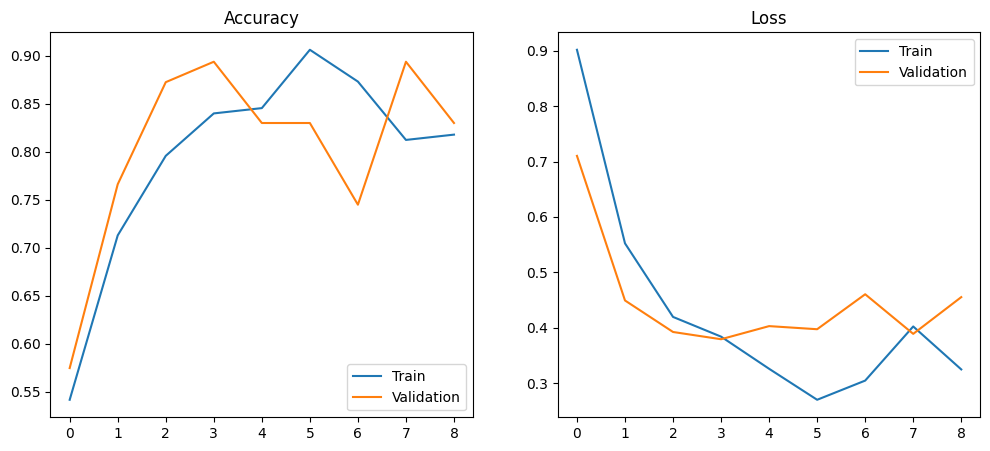

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.legend(['Train','Validation'])

plt.show()

# Evaluation of MobileNetV2

The transfer learning model is evaluated using the same metrics as the baseline CNN.

Performance improvements over the custom CNN are expected due to pretrained feature representations.

In [42]:
y_true = validation_generator.classes

y_prob = model.predict(validation_generator)

y_pred = (y_prob > 0.5).astype(int).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


In [43]:
print( classification_report( y_true, y_pred, target_names=['No Tumor','Tumor']))

              precision    recall  f1-score   support

    No Tumor       0.84      0.89      0.86        18
       Tumor       0.93      0.90      0.91        29

    accuracy                           0.89        47
   macro avg       0.89      0.89      0.89        47
weighted avg       0.90      0.89      0.89        47



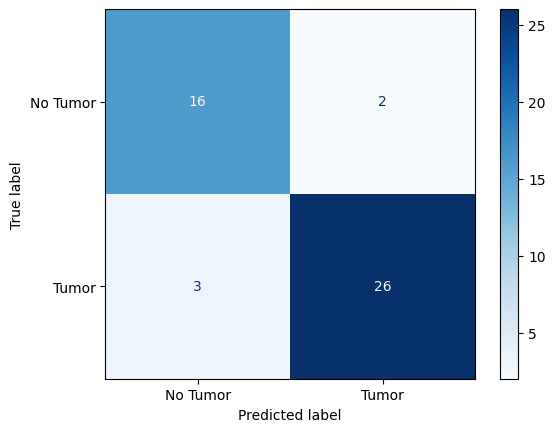

In [44]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=['No Tumor', 'Tumor']).plot(cmap='Blues')

plt.show()

In [45]:
model.save(
    "/kaggle/working/mobilenetv2_brain_tumor.keras"
)

# Fine-Tuning the Pretrained Model

After training the classifier head:

1. Selected MobileNetV2 layers are unfrozen.
2. A very small learning rate is used.
3. The network adapts ImageNet features to MRI images.

Fine-tuning often provides the best performance.

In [46]:
base_model.trainable = True

In [47]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [48]:
model.compile( optimizer=tf.keras.optimizers.Adam( learning_rate=1e-5 ), loss='binary_crossentropy',
    metrics=['accuracy'] )

In [49]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True )

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop] )

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6685 - loss: 0.9465 - val_accuracy: 0.8298 - val_loss: 0.3936
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.6796 - loss: 0.8609 - val_accuracy: 0.8298 - val_loss: 0.4238
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.7348 - loss: 0.6718 - val_accuracy: 0.7872 - val_loss: 0.4569
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.7514 - loss: 0.6700 - val_accuracy: 0.7872 - val_loss: 0.4848


In [50]:
acc = history.history['accuracy'] + history_finetune.history['accuracy']

val_acc = (
    history.history['val_accuracy']
    + history_finetune.history['val_accuracy']
)

loss = (
    history.history['loss']
    + history_finetune.history['loss']
)

val_loss = (
    history.history['val_loss']
    + history_finetune.history['val_loss']
)

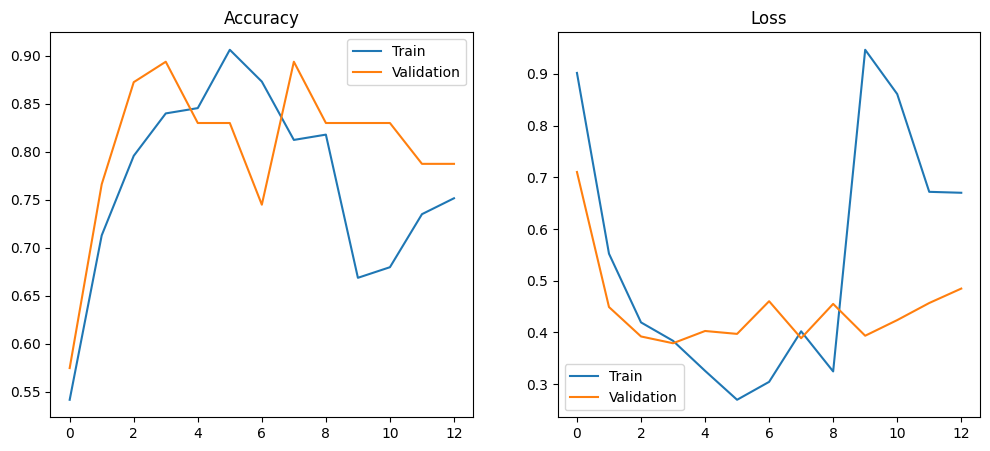

In [51]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc)
plt.plot(val_acc)
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(loss)
plt.plot(val_loss)
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Final Model Evaluation

The fine-tuned MobileNetV2 model is evaluated on the validation dataset.

Metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [52]:
from sklearn.metrics import classification_report

y_true = validation_generator.classes

y_prob = model.predict(validation_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

1/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f59b3842980> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
              precision    recall  f1-score   support

    No Tumor       0.73      0.89      0.80        18
       Tumor       0.92      0.79      0.85        29

    accuracy                           0.83

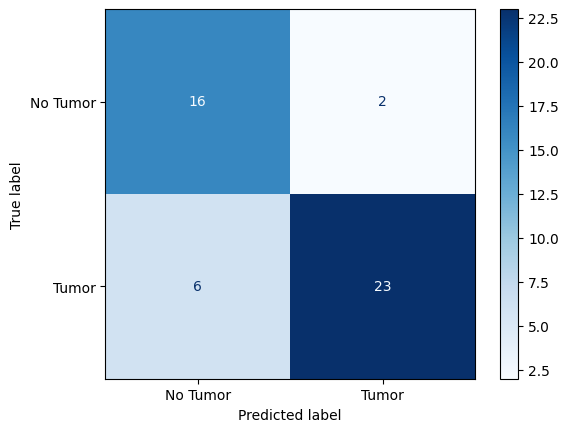

In [53]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
).plot(cmap='Blues')

plt.show()

In [54]:
model.save('/kaggle/working/brain_tumor_model_final.keras')

In [55]:
print(model.input_shape)

(None, 224, 224, 3)


Shape before preprocessing: (224, 224, 3)
Shape after preprocessing: (1, 224, 224, 3)


2026-06-18 17:16:02.186949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 17:16:02.326269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


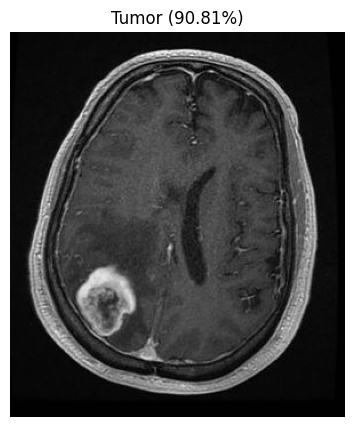

In [56]:
img_path = os.path.join(
    val_yes,
    os.listdir(val_yes)[21]
)

# Open image and convert to RGB
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')

# Resize image
img_resized = img.resize((224,224))

# Convert to NumPy array
img_array = np.array(
    img_resized,
    dtype=np.float32
)

print("Shape before preprocessing:",
      img_array.shape)

# MobileNetV2 preprocessing
img_array = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(img_array)
)

# Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

print("Shape after preprocessing:",
      img_array.shape)

# Prediction
pred = model.predict(
    img_array,
    verbose=0
)[0][0]

label = (
    "Tumor"
    if pred > 0.5
    else "No Tumor"
)

confidence = (
    pred if pred > 0.5
    else 1 - pred
)

plt.title(
    f"{label} ({confidence:.2%})"
)

plt.show()

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,803,077 (22.14 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,380,996 (12.90 MB)

# Model Explainability using Grad-CAM

Deep learning models are often considered "black boxes".

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize:

- Which regions influenced the prediction
- Whether the model focuses on tumor regions
- Clinical interpretability of the decision

This improves trust and transparency.

In [58]:
base_model = model.layers[0]

classifier = tf.keras.Sequential(
    model.layers[1:]
)

In [59]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(
        "out_relu"
    ).output
)

In [60]:
img_path = os.path.join(
    val_yes,
    os.listdir(val_yes)[11]
)

img = Image.open(
    img_path
).convert("RGB")

img = img.resize(
    (224,224)
)

img_array = np.array(
    img,
    dtype=np.float32
)

img_array = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        img_array
    )
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [61]:
def make_gradcam_heatmap(
        img_array,
        grad_model,
        classifier):

    with tf.GradientTape() as tape:

        conv_outputs = grad_model(
            img_array
        )

        tape.watch(
            conv_outputs
        )

        predictions = classifier(
            conv_outputs
        )

        loss = predictions[:,0]

    grads = tape.gradient(
        loss,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(
            heatmap
        ) + 1e-8
    )

    return heatmap.numpy()

In [62]:
heatmap = make_gradcam_heatmap(
    img_array,
    grad_model,
    classifier
)

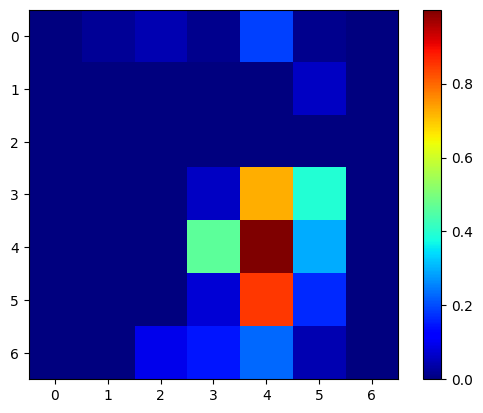

In [63]:
plt.imshow(
    heatmap,
    cmap='jet'
)
plt.colorbar()
plt.show()

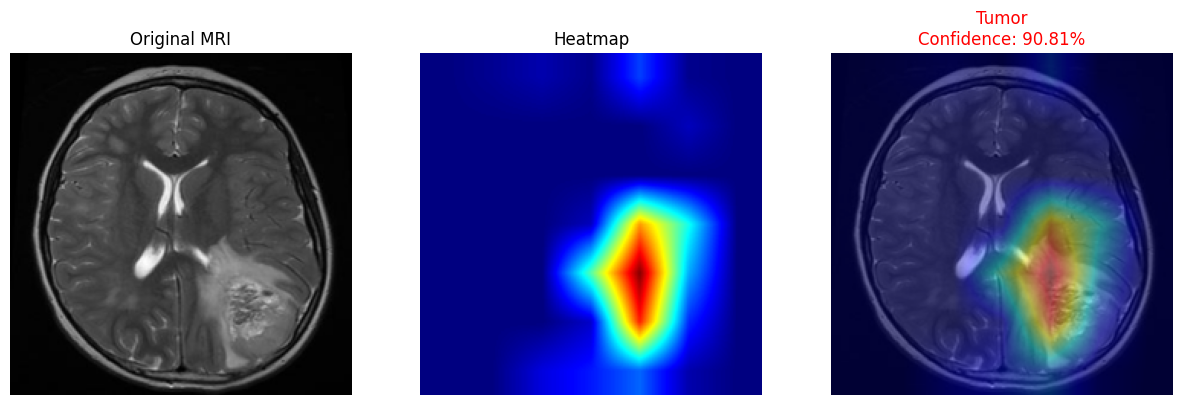

In [64]:
import cv2

original_img = Image.open(
    img_path
).convert("RGB")

original_img = original_img.resize(
    (224,224)
)

original_img = np.array(
    original_img
)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original_img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    heatmap_color[:,:,::-1]
)
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    superimposed_img[:,:,::-1]
)

confidence = pred if pred > 0.5 else 1 - pred

plt.title(
    f"{label}\nConfidence: {confidence:.2%}",
    fontsize=12,
    color='red'
)

plt.axis("off")

plt.show()

# Conclusion

In this notebook:

- MRI images were analyzed and cleaned.
- Duplicate samples were removed.
- A baseline CNN was trained.
- Transfer learning with MobileNetV2 significantly improved performance.
- Fine-tuning further enhanced accuracy.
- Grad-CAM provided visual explanations of model predictions.

Future Improvements:

- Larger MRI datasets
- Cross-validation
- EfficientNet or ConvNeXt architectures
- Clinical-grade evaluation on multi-center datasets
- Deployment using TensorFlow Lite or ONNX